# Global Fit of Light-Induced Synaptic Behavior
This notebook demonstrates the global fitting of light-induced synaptic behavior curves across different light power densities. We fit the kinetic parameters of a model to multiple experimental curves simultaneously.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from scipy.optimize import curve_fit
from functions_general import *
%matplotlib widget

## Obtain Data

In this step, we load the preprocessed experimental data from a tab-separated text file. The dataset contains time-series measurements for multiple curves, where each column represents the synaptic response (intensity) to a specific laser power density. We extract the time vector, intensity matrix, and parse the power density values from the column headers.

In [2]:
plt.close('all')
input_filename = 'Ton_10min_Toff_30min_ND0_preprocessed_data'
path_file = fr'./Input data for fitting/{input_filename}.txt'

idx_initial_curve = 1
idx_final_curve = None
data = pd.read_csv(path_file, sep='\t')
time_data = data['Time (s)'].to_numpy()
intensity_matrix = data.iloc[:, idx_initial_curve:idx_final_curve].to_numpy()
power_density_labels = data.columns[idx_initial_curve:idx_final_curve].to_numpy()
power_density_vector = [float(label.split('= ')[1].split('nW')[0]) for label in power_density_labels]

### Define Laser Pulse and Plot Raw Data

Here, we define the laser pulse timing profile using a list of impulses (start time, end time, and normalized amplitude). We then generate a base laser power vector and plot the raw experimental curves alongside the laser pulse shape to visually verify their alignment and timing.

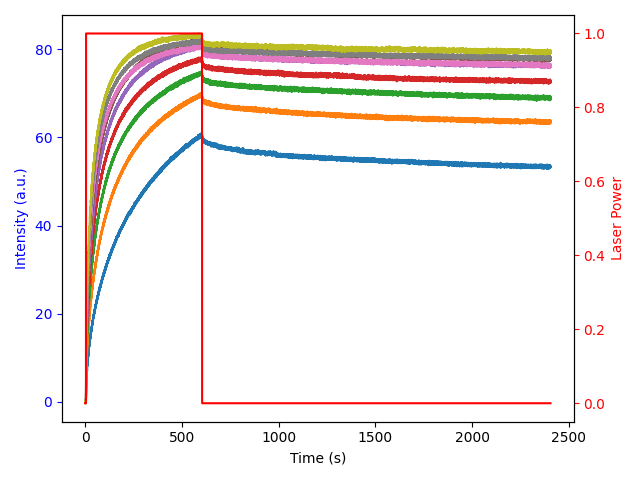

In [3]:
defined_zero = 0
laser_power_base = np.ones(len(time_data))*defined_zero

impulse_list = [
    # t1, t2, amplitude
    (4.114, 604, 1.0)
]

laser_power_base = add_pulses(impulse_list, time_data, laser_power_base)
fig, ax1 = plt.subplots()

for i in range(intensity_matrix.shape[1]):
    ax1.plot(time_data, intensity_matrix[:, i], label=f'{power_density_vector[i]} nW*um^-2')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Intensity (a.u.)', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(time_data, laser_power_base, 'r-', label='Laser Power')
ax2.set_ylabel('Laser Power', color='r')
ax2.tick_params('y', colors='r')

fig.tight_layout()
plt.show()

## 2. Prepare Data Lists for Global Fit

To optimize the fitting speed, we downsample the time series, intensity matrix, and laser power curves by a specified factor. We then structure the data into lists of arrays (one array per curve) as required by the `GlobalFitManager`.

In [4]:
downsampling_factor = 50
time_list = []
power_list = []
intensity_list = []

for i in range(len(power_density_vector)):
    power_density = power_density_vector[i]
    t_d = time_data[::downsampling_factor]
    i_d = intensity_matrix[::downsampling_factor, i]
    p_d = power_density * laser_power_base[::downsampling_factor]
    
    time_list.append(t_d)
    intensity_list.append(i_d)
    power_list.append(p_d)

print(f"Prepared {len(intensity_list)} curves for global fitting.")

Prepared 9 curves for global fitting.


### Plot Downsampled Data

Here, we plot the downsampled intensity curves and the normalized laser pulse shape to verify that the downsampling preserves the key dynamical features of the data before we start the optimization process.

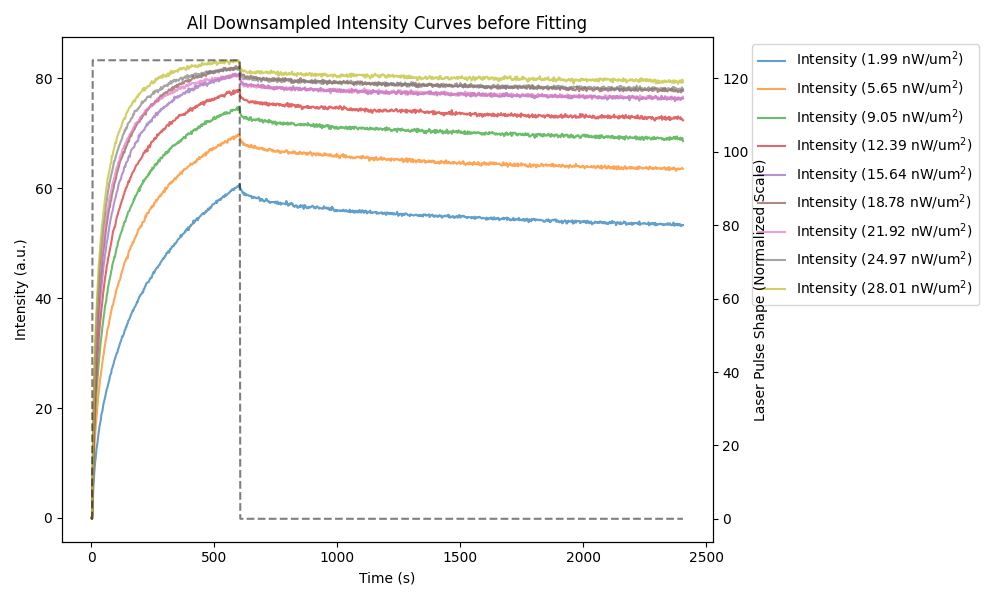

In [5]:
if intensity_list and power_list:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    for i in range(len(intensity_list)):
        t_plot = time_list[i]
        i_plot = intensity_list[i]
        power_density = power_density_vector[i]
        
        color = colors[i % len(colors)]
        ax1.plot(t_plot, i_plot, '-', 
                 label=f'Intensity ({power_density} nW/um$^2$)', 
                 alpha=0.7, color=color)

    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Intensity (a.u.)')
    ax1.set_title('All Downsampled Intensity Curves before Fitting')
    ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    
    ax2 = ax1.twinx()
    p_ref = power_list[0]
    t_ref = time_list[0]
    
    max_p = np.max(p_ref)
    p_normalized = p_ref / max_p if max_p > 0 else np.zeros_like(p_ref)

    visualization_scale = np.max(intensity_list) * 1.5 
    ax2.plot(t_ref, p_normalized * visualization_scale, 'k--', label='Laser Pulse Shape (Scaled)', alpha=0.5)
    
    ax2.set_ylabel('Laser Pulse Shape (Normalized Scale)', color='k')
    ax2.tick_params('y', colors='k')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.05, 1))

    fig.tight_layout(rect=[0, 0, 1.0, 1])
    plt.show()

## 3. Global Fit Configuration

In this section, we define the parameters for the global fit. We configure:
* `init_val_dict`: The starting values for the parameters.
* `var_dict`: A boolean dictionary indicating which parameters are free to be fitted (`1`) and which should remain fixed (`0`).
* `fit_global`: A boolean dictionary indicating whether a parameter is global/shared across all curves (`1`) or local/independent for each curve (`0`).

In [6]:
init_val_dict = {
    'kp1': 0.01,
    'kd1': 5e-6,
    'Imax1': 50,
    'kp2': 0.001,
    'kd2': 1e-15,
    'Imax2': 50
}

# 1 = fit parameter, 0 = keep fixed at initial value
var_dict = {
    'kp1': 1,
    'kd1': 1,
    'Imax1': 1,
    'kp2': 1,
    'kd2': 1,
    'Imax2': 1
}

# 1 = global parameter (shared), 0 = local parameter (independent)
fit_global = {
    'kp1': 0,
    'kd1': 1,
    'Imax1': 1,
    'kp2': 0,
    'kd2': 1,
    'Imax2': 1
}

## 4. Run the Fit

We instantiate the `GlobalFitManager` with our model function and lists of downsampled data. We then run the fit using the defined parameters. The fit results and $R^2$ goodness-of-fit values are printed as a table.

In [7]:
global_fitter = GlobalFitManager(model_fit_double_rate_dict, time_list, power_list, intensity_list)
global_fitter.setup_parameters(init_val_dict, var_dict, fit_global)
results_df = global_fitter.run_fit()

if results_df is not None:
    results_df.insert(0, 'P (nW*um^-2)', power_density_vector)
    print("Global Fit Results:")
    print(results_df)
    print("\nR2 error vector:")
    print(global_fitter.calculate_R2(results_df))

Starting global fit with 22 free parameters...
Fit completed successfully.
Global Fit Results:
   P (nW*um^-2)  Curve_Index       kp1       kd1      Imax1       kp2  \
0          1.99            0  0.007901  0.000047  50.266315  0.000469   
1          5.65            1  0.015116  0.000047  50.266315  0.001317   
2          9.05            2  0.023071  0.000047  50.266315  0.002129   
3         12.39            3  0.030881  0.000047  50.266315  0.003022   
4         15.64            4  0.036000  0.000047  50.266315  0.004703   
5         18.78            5  0.040118  0.000047  50.266315  0.006360   
6         21.92            6  0.050966  0.000047  50.266315  0.005297   
7         24.97            7  0.053142  0.000047  50.266315  0.007550   
8         28.01            8  0.054596  0.000047  50.266315  0.010137   

            kd2      Imax2  
0  1.665014e-39  31.304026  
1  1.665014e-39  31.304026  
2  1.665014e-39  31.304026  
3  1.665014e-39  31.304026  
4  1.665014e-39  31.304026  


### Visualize Fit Results

Finally, we plot the fitted curves against the raw experimental data to visually inspect the quality of the fit. We also plot the optimized local parameters as a function of power density to analyze their dependency on light intensity.

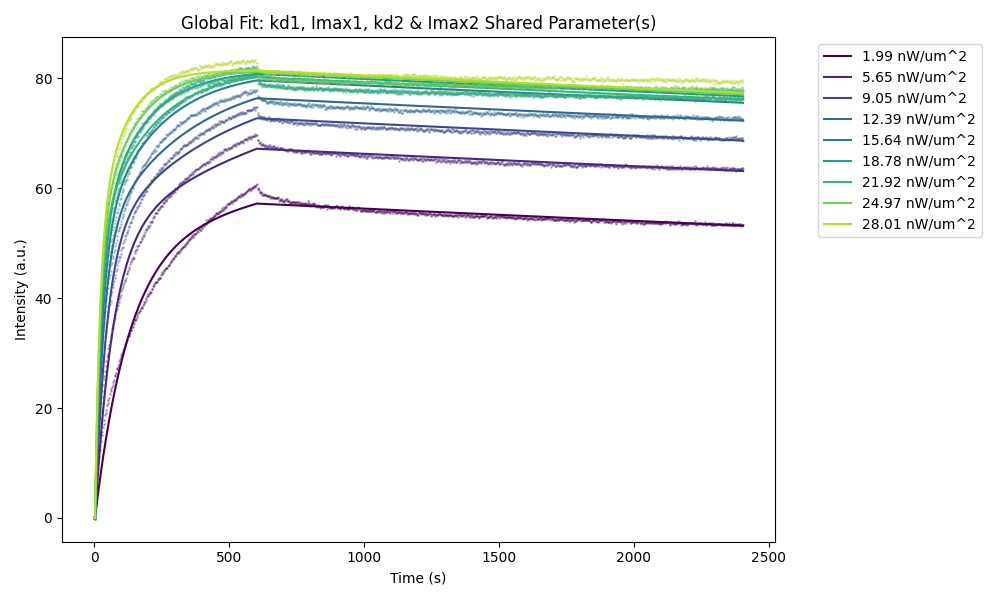

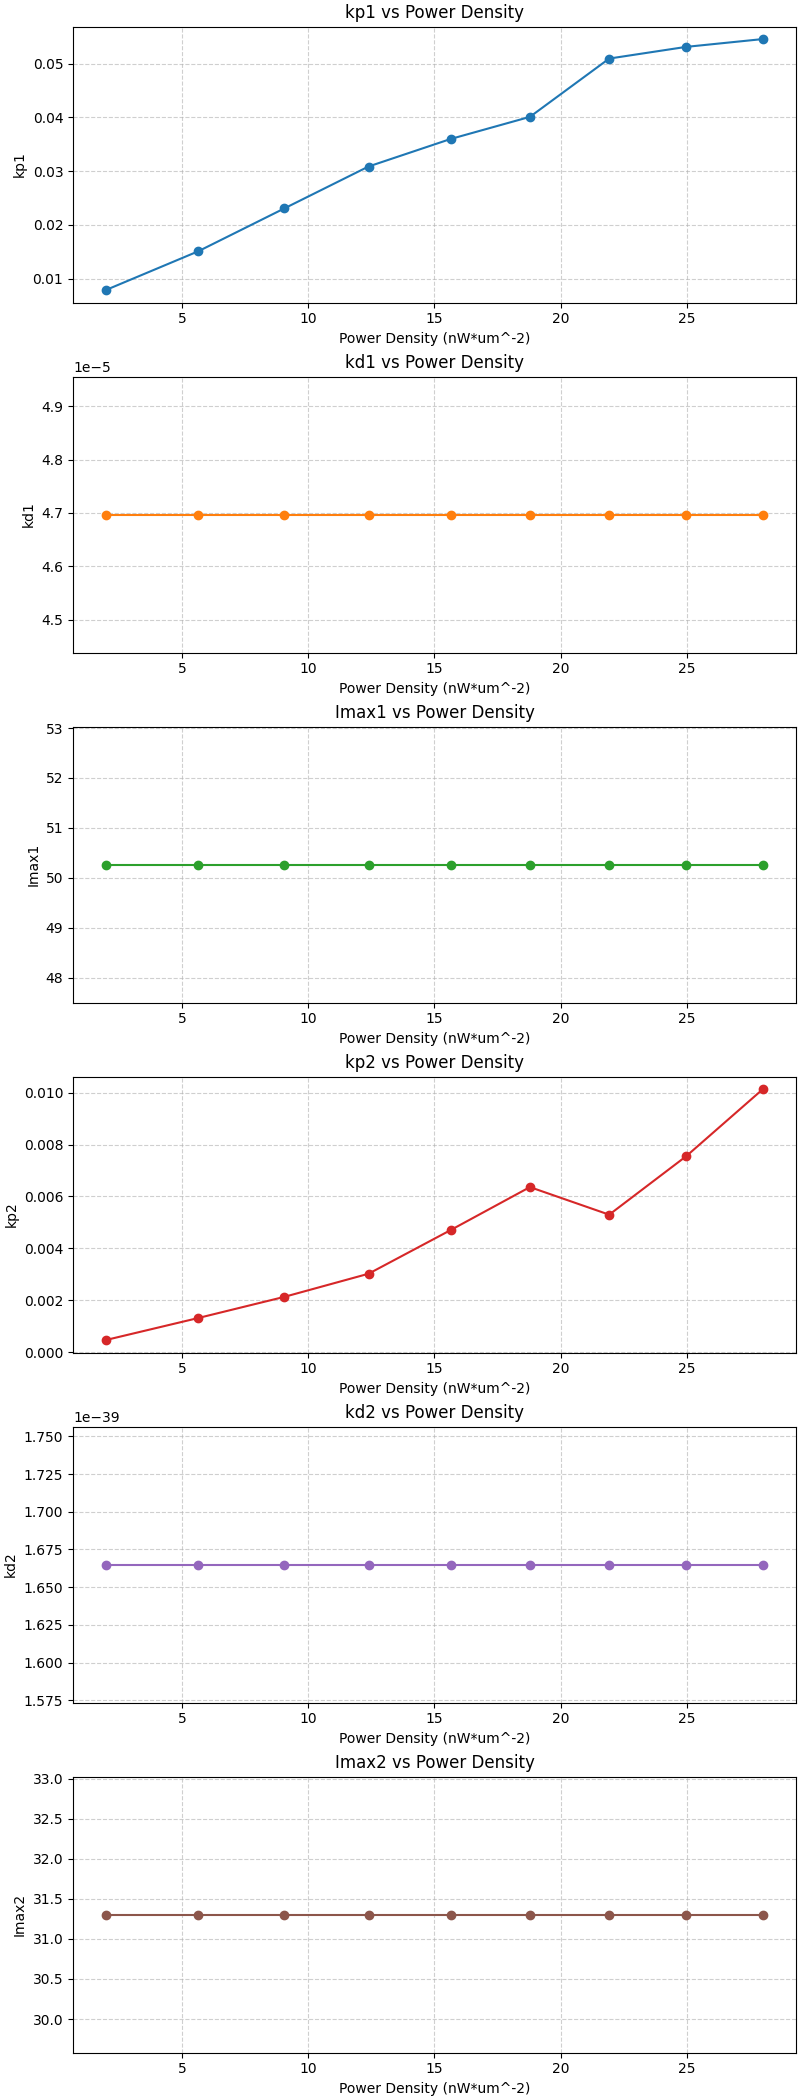

In [8]:
# Determine dynamic title based on global fitted parameters
global_fitted_params = [
    k for k in init_val_dict.keys() 
    if var_dict.get(k, 0) == 1 and fit_global.get(k, 0) == 1
]

if global_fitted_params:
    if len(global_fitted_params) > 1:
        shared_params_str = ', '.join(global_fitted_params[:-1]) + ' & ' + global_fitted_params[-1]
    else:
        shared_params_str = global_fitted_params[0]
    dynamic_title = f'Global Fit: {shared_params_str} Shared Parameter(s)'
else:
    dynamic_title = 'Global Fit: Local/Independent Curves'

if results_df is not None:
    plt.figure(figsize=(10, 6))
    
    for i in range(len(time_list)):
        t = time_list[i]
        p = power_list[i]
        real_intensity = intensity_list[i]
        power_val = power_density_vector[i]
        
        best_params = results_df.iloc[i].to_dict()
        fit_intensity, _, _ = model_fit_double_rate_dict(t, p, best_params)
        
        color = plt.cm.viridis(i / len(time_list))
        plt.plot(t, real_intensity, '.', markersize=2, alpha=0.3, color=color)
        plt.plot(t, fit_intensity, '-', linewidth=1.5, label=f'{power_val} nW/um^2', color=color)

    plt.xlabel('Time (s)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(dynamic_title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if results_df is not None:
    # Exclude identification columns to get parameters
    param_columns = results_df.columns.drop(['Curve_Index', 'P (nW*um^-2)'])
    num_params = len(param_columns)
    
    fig, axs = plt.subplots(num_params, 1, figsize=(8, 3.5 * num_params), constrained_layout=True)
    if num_params == 1:
        axs = [axs]
        
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    for i, param_name in enumerate(param_columns):
        color = colors[i % len(colors)]
        axs[i].plot(
            results_df['P (nW*um^-2)'], 
            results_df[param_name], 
            'o-', 
            label=param_name, 
            color=color
        )
        axs[i].set_title(f'{param_name} vs Power Density')
        axs[i].set_xlabel('Power Density (nW*um^-2)')
        axs[i].set_ylabel(param_name)
        axs[i].grid(True, linestyle='--', alpha=0.6)

    plt.show()